# Predicting Hospital Readmission in Diabetic Patients
## Notebook 2 of 7 - Exploratory Data Analysis (EDA)


In this notebook I performed exploratory data analysis on the **raw** `diabetic_data.csv` file before any preprocessing was applied. I computed all summary statistics directly from the original data to preserve transparency and to inform the cleaning decisions I made in `1_DataCleaning_PM.ipynb`.

**Figures I produced:**
- Figure 1: Patient Demographics (race, gender, age)
- Figure 2: Readmission Class Distribution
- Figure 3: Numeric Variable Distributions (log-scale)

## 1. Import Libraries & Plot Configuration

I defined my color palette and global plot settings once here so I didn't have to repeat them in every chart.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# rcParams sets default styles that apply to every plot
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11
})

BLUE   = '#4A90D9'
RED    = '#2C3E8C'
COLORS = ['#4A90D9', '#7B5EA7', '#2C3E8C', '#9B59B6',
          '#5DADE2', '#B8A9D9', '#1A237E', '#6C3483']

## 2. Load Raw Dataset

In [2]:
diabetic = pd.read_csv('diabetic_data.csv')
df = diabetic.copy()

# I created a temporary numeric age column for EDA calculations only
# The permanent mapping lives in 1_DataCleaning_PM.ipynb
age_mapping = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3,
    '[40-50)': 4, '[50-60)': 5, '[60-70)': 6, '[70-80)': 7,
    '[80-90)': 8, '[90-100)': 9
}
df['age_numeric'] = df['age'].map(age_mapping)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 101,766 rows × 51 columns


## 3. Dataset Shape

I printed these to confirm the file loaded correctly before doing any analysis.

In [3]:
print("Dataset Shape")
print(f"Total encounters (rows): {len(df):,}")
print(f"Total features (columns): {df.shape[1]}")
print(f"Unique patients: {df['patient_nbr'].nunique():,}")

Dataset Shape
Total encounters (rows): 101,766
Total features (columns): 51
Unique patients: 71,518


## 4. Patient Demographics - Summary Statistics

In [4]:
print("\nRace:")
race_counts = df['race'].value_counts(dropna=False)
race_percentage = df['race'].value_counts(normalize=True, dropna=False) * 100
for val in race_counts.index:
    print(f"  {val}: {race_counts[val]:,} ({race_percentage[val]:.1f}%)")

print("\nGender:")
gender_counts = df['gender'].value_counts(dropna=False)
gender_percentage = df['gender'].value_counts(normalize=True, dropna=False) * 100
for val in gender_counts.index:
    print(f"  {val}: {gender_counts[val]:,} ({gender_percentage[val]:.1f}%)")

print("\nAge groups:")
age_counts = df['age'].value_counts().sort_index()  # sort_index keeps intervals in chronological order
age_percentage = df['age'].value_counts(normalize=True).sort_index() * 100
for val in age_counts.index:
    print(f"  {val}: {age_counts[val]:,} ({age_percentage[val]:.1f}%)")

over_60 = df[df['age_numeric'] >= 6]
print(f"\nPatients over 60: {len(over_60):,} ({len(over_60)/len(df)*100:.1f}%)")


Race:
  Caucasian: 76,099 (74.8%)
  AfricanAmerican: 19,210 (18.9%)
  ?: 2,273 (2.2%)
  Hispanic: 2,037 (2.0%)
  Other: 1,506 (1.5%)
  Asian: 641 (0.6%)

Gender:
  Female: 54,708 (53.8%)
  Male: 47,055 (46.2%)
  Unknown/Invalid: 3 (0.0%)

Age groups:
  [0-10): 161 (0.2%)
  [10-20): 691 (0.7%)
  [20-30): 1,657 (1.6%)
  [30-40): 3,775 (3.7%)
  [40-50): 9,685 (9.5%)
  [50-60): 17,256 (17.0%)
  [60-70): 22,483 (22.1%)
  [70-80): 26,068 (25.6%)
  [80-90): 17,197 (16.9%)
  [90-100): 2,793 (2.7%)

Patients over 60: 68,541 (67.4%)


## 5. Figure 1: Patient Demographics

Looking at race, I found the dataset was heavily skewed toward Caucasian patients at 74.8% of encounters, with African American patients making up 18.9%. Gender was nearly balanced at 53.8% female and 46.2% male. The age distribution was one of the more telling findings - encounter volume peaked in the 70–80 interval, and 66.2% of patients were over 60, which aligned with what Strack et al. observed about the demographics of Type 2 diabetes.

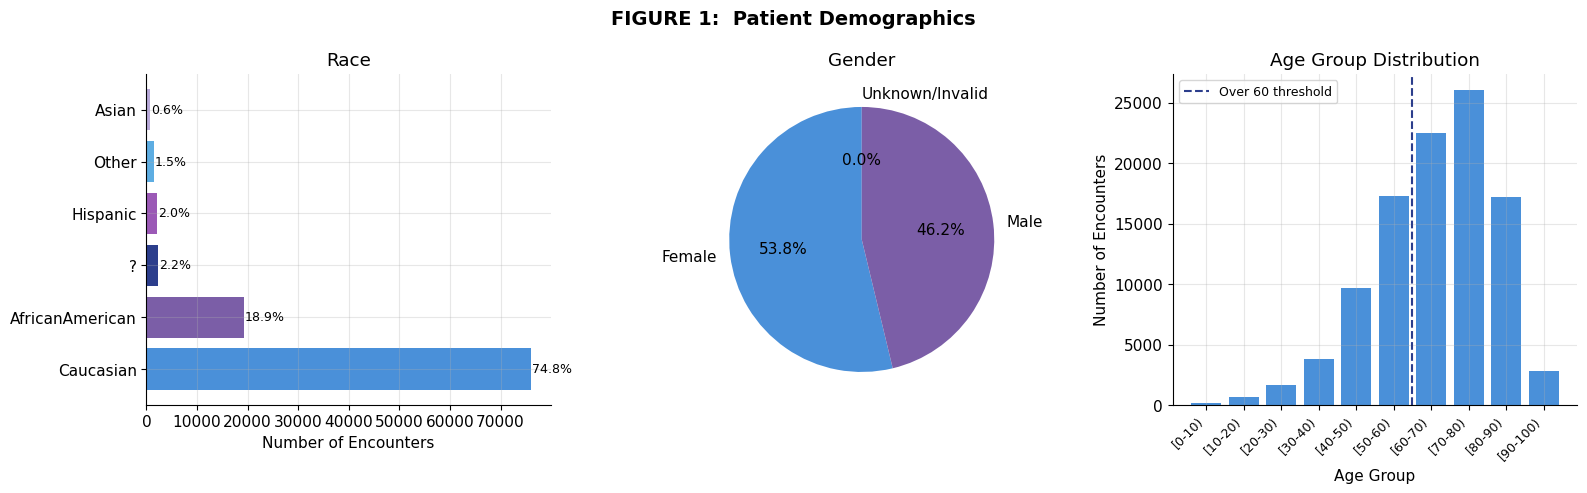

Saved to 'plotting_patient_demographics.png'


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('FIGURE 1:  Patient Demographics', fontsize=14, fontweight='bold')

# Race — horizontal bar so the category labels are easy to read
race_plot = df['race'].fillna('Not Recorded').value_counts()
axes[0].barh(race_plot.index, race_plot.values, color=COLORS[:len(race_plot)])
axes[0].set_title('Race')
axes[0].set_xlabel('Number of Encounters')
for i, v in enumerate(race_plot.values):
    axes[0].text(v + 200, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=9)

# Gender — pie chart since there were only two meaningful categories
gender_plot = df['gender'].value_counts()
axes[1].pie(gender_plot.values, labels=gender_plot.index,
            autopct='%1.1f%%', colors=['#4A90D9', '#7B5EA7'], startangle=90)
axes[1].set_title('Gender')

# Age — bar chart with a dashed line marking the over-60 cutoff
age_plot = df['age'].value_counts().sort_index()
axes[2].bar(range(len(age_plot)), age_plot.values, color=BLUE)
axes[2].set_xticks(range(len(age_plot)))
axes[2].set_xticklabels(age_plot.index, rotation=45, ha='right', fontsize=9)
axes[2].set_title('Age Group Distribution')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Number of Encounters')
axes[2].axvline(x=5.5, color=RED, linestyle='--', linewidth=1.5, label='Over 60 threshold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plotting_patient_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 'plotting_patient_demographics.png'")

## 6. Target Variable - Class Distribution

The breakdown of the target variable revealed a significant class imbalance that was one of the first challenges I had to address. A model that simply predicted no readmission for every patient would still be right about 54% of the time while never correctly identifying a single early readmission case - completely useless in a clinical setting. This imbalance directly shaped every modeling decision I made in the sections that followed.

In [6]:
print("Target Variable: Readmission Class Distribution")
readmit_counts = df['readmitted'].value_counts()
readmit_percentage = df['readmitted'].value_counts(normalize=True) * 100
for val in readmit_counts.index:
    print(f"  {val}: {readmit_counts[val]:,} ({readmit_percentage[val]:.1f}%)")

Target Variable: Readmission Class Distribution
  NO: 54,864 (53.9%)
  >30: 35,545 (34.9%)
  <30: 11,357 (11.2%)


## 7. Figure 2: Readmission Class Distribution

I fixed the order and colors so both panels were consistent with each other. I also exploded the `<30` slice in the pie chart to draw attention to the minority class.

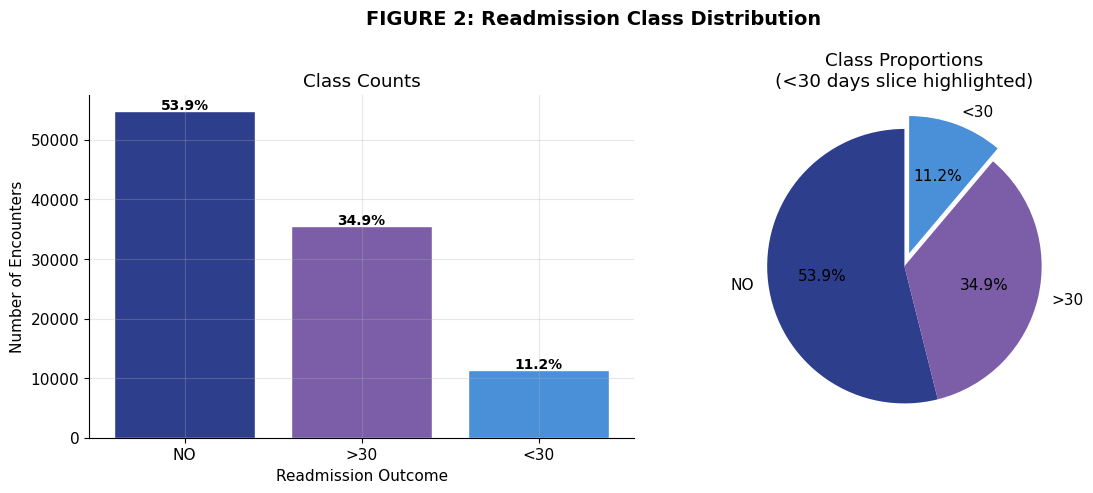

Saved to 'plotting_class_distribution.png'


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('FIGURE 2: Readmission Class Distribution', fontsize=14, fontweight='bold')

class_colors = {'NO': '#2C3E8C', '>30': '#7B5EA7', '<30': '#4A90D9'}
plot_order   = ['NO', '>30', '<30']
plot_colors  = [class_colors[c] for c in plot_order]
plot_values  = [readmit_counts.get(c, 0) for c in plot_order]
plot_pcts    = [readmit_percentage.get(c, 0) for c in plot_order]

# Bar chart with percentage labels
bars = axes[0].bar(plot_order, plot_values, color=plot_colors, edgecolor='white')
axes[0].set_title('Class Counts')
axes[0].set_xlabel('Readmission Outcome')
axes[0].set_ylabel('Number of Encounters')
for bar, pct in zip(bars, plot_pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Pie chart — explode pulls the <30 slice outward to highlight the minority class
axes[1].pie(plot_values, labels=plot_order, autopct='%1.1f%%',
            colors=plot_colors, startangle=90, explode=(0, 0, 0.1))
axes[1].set_title('Class Proportions\n(<30 days slice highlighted)')

plt.tight_layout()
plt.savefig('plotting_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 'plotting_class_distribution.png'")

## 8. Numeric Variable Summary Statistics

I used this to spot skew and verify the variable ranges I cited in my final report.

In [8]:
numeric_columns = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses"
]
print("Numeric Variable Summary Statistics")
df[numeric_columns].describe().round(2)

Numeric Variable Summary Statistics


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


## 9. Figure 3: Numeric Variable Distributions

I applied a **log scale** to the x-axis because the utilization variables (outpatient, emergency, and inpatient visits) were heavily right-skewed. Most patients had zero or one prior visit in each category, but a small number had many, creating a long right tail that made the distributions nearly unreadable at a linear scale. One thing that stood out was the sharp spike at 9 in `number_diagnoses`, which reflected a data entry ceiling in the original system rather than anything clinically meaningful - I noted this as a data artifact.

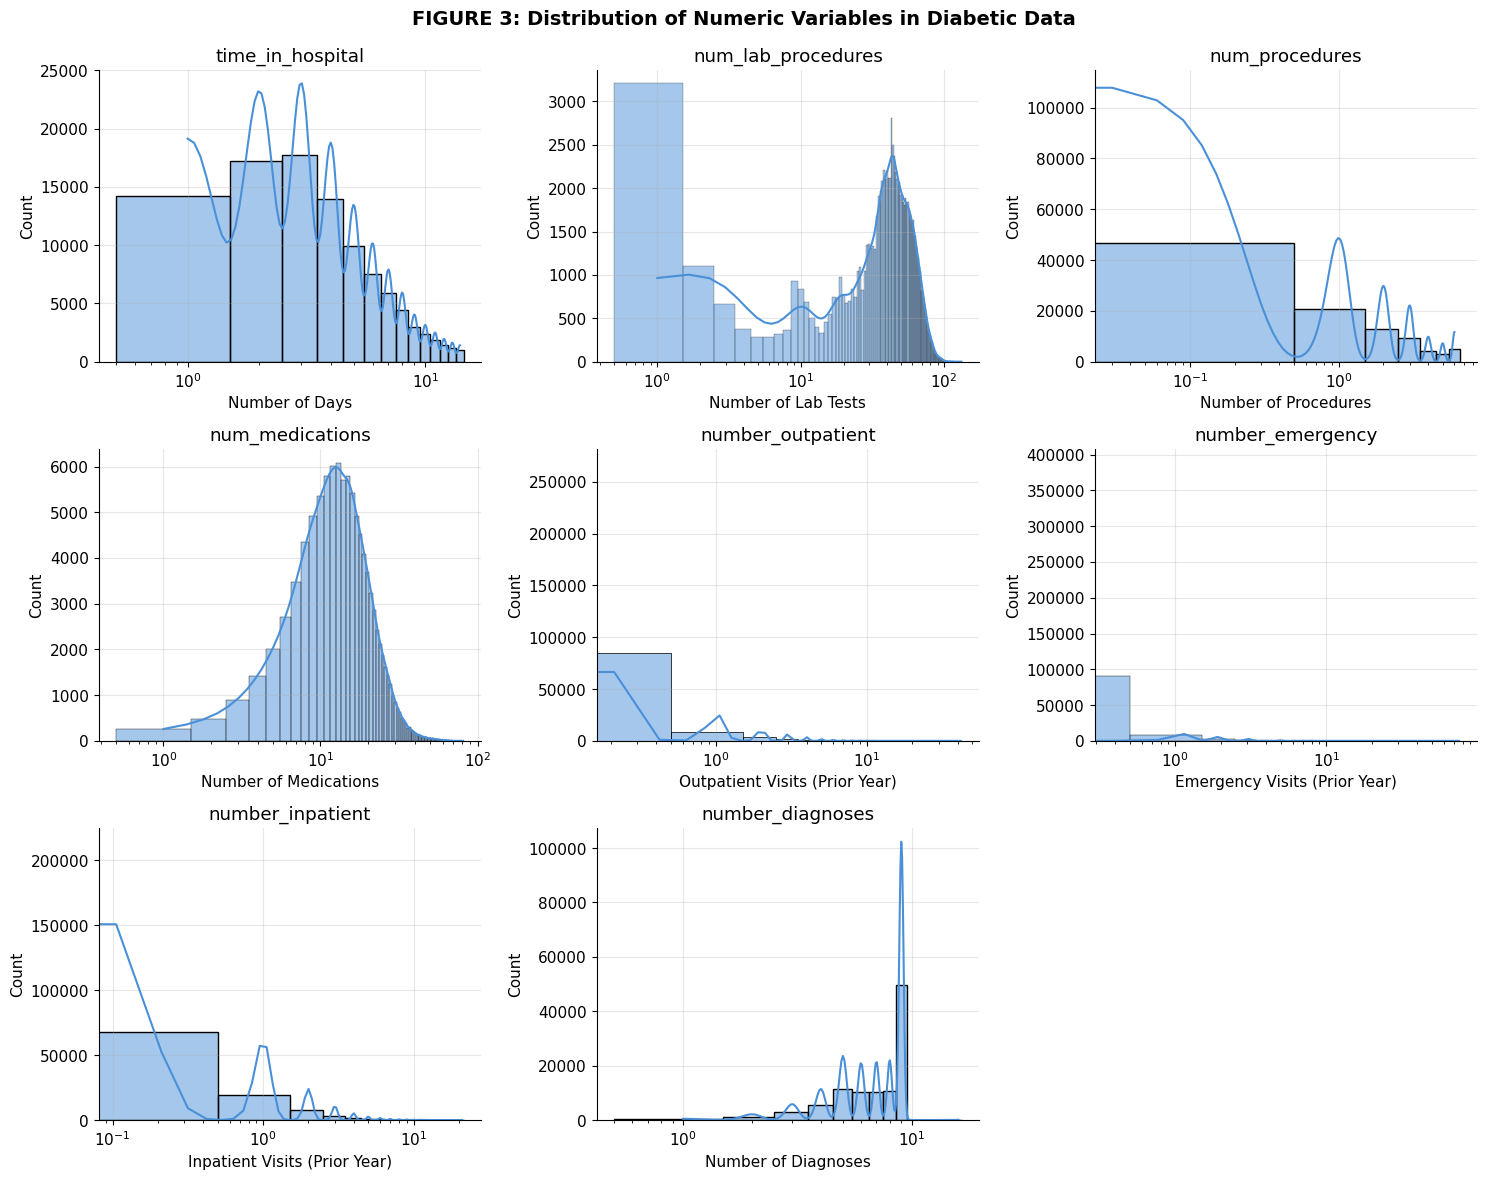

Saved to 'plotting_numeric_distributions.png'


In [9]:
axis_labels = {
    "time_in_hospital":    "Number of Days",
    "num_lab_procedures":  "Number of Lab Tests",
    "num_procedures":      "Number of Procedures",
    "num_medications":     "Number of Medications",
    "number_outpatient":   "Outpatient Visits (Prior Year)",
    "number_emergency":    "Emergency Visits (Prior Year)",
    "number_inpatient":    "Inpatient Visits (Prior Year)",
    "number_diagnoses":    "Number of Diagnoses"
}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # flatten converts the 3x3 grid into a flat list so I could loop with one index

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], ax=axes[i], kde=True, discrete=True, color=BLUE)
    axes[i].set_title(col)
    axes[i].set_xlabel(axis_labels[col])
    axes[i].set_xscale('log')  # log scale compresses the long right tail so the shape is visible

axes[-1].set_visible(False)  # I hid the 9th panel since there were only 8 variables

plt.suptitle("FIGURE 3: Distribution of Numeric Variables in Diabetic Data",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('plotting_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 'plotting_numeric_distributions.png'")